# Load Libraries

In [1]:


%load_ext autoreload
%autoreload 2



# Basic libraries
import pandas as pd
import numpy as np
import sys



# Scipy
import scipy
from scipy import signal
from scipy.linalg import solve
from scipy import constants
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# Locate files
import os
from pathlib import Path
from glob import glob

# Plots
from matplotlib import pyplot as plt

#Important!! Make sure your current directory is the MHDTurbPy folder!
os.chdir("/Users/turbulator/work/MHDTurbPy")


# Make sure to use the local spedas
sys.path.insert(0, os.path.join(os.getcwd(), 'pyspedas'))
import pyspedas
from pyspedas.utilities import time_string
from pytplot import get_data
from joblib import Parallel, delayed

""" Import manual functions """

sys.path.insert(1, os.path.join(os.getcwd(), 'functions'))
import calc_diagnostics as calc
import TurbPy as turb
import general_functions as func
import Figures as figs

from   SEA import SEA
import three_D_funcs as threeD
import download_data as download

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/3d_anis_analysis_toolboox'))
import collect_wave_coeffs 
import data_analysis 



os.environ["CDF_LIB"] = "/Applications/cdf/cdf/lib"


/Users/turbulator/work/MHDTurbPy/pyspedas/pyspedas/__init__.py


# The distance data are a bit problematic. Download and save them

In [90]:
cdf_lib_path = "/Applications/cdf/cdf/lib"

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/downloading_helpers'))
#from  PSP import  LoadTimeSeriesPSP, download_ephemeris_PSP
from  SOLO import *


save_path  ='/Users/turbulator/work/turb_amplitudes/SOLO/'
fname      = 'solo_dist.pkl'
t0, t1     ='2020-06-01', '2025-01-01'
dfmag      =  download_ephem_SOLO(t0, t1, cdf_lib_path)

dfmag      = dfmag.resample('5min').asfreq().interpolate(method='linear')
dist_df    = pd.DataFrame(dfmag['Dist_au'])
func.savepickle(dist_df, save_path, fname)

# Download data


In [8]:

#User defined parameters 

cdf_lib_path            = '/Applications/cdf/cdf/lib'            # You will need to read cdf files. You have to specify the path

""" At this point you NEED credentials for function to work. This is because of the ephemeris data! Let me know if this doesnt work"""


credentials             =      { 'psp':{
                                           'fields': {'username': 'mvelli', 'password': 'flds@psp'},
                                           'sweap' : {'username': 'mvelli', 'password': '2019swe@pd@ta'}}}



settings                =  {
    
                    ###____How to handle data ____###
                            'SOLO_dist_path'         : '/Users/turbulator/work/turb_amplitudes/SOLO/solo_dist.pkl',
                            'Data_path'              : '/Users/turbulator/work/Data/',  # Path were pyspedas downloads data
                            'save_destination'       : '/Users/turbulator/work/MHDTurbPy/examples/',#'/Users/turbulator/work/MHDTurbPy/examples/',
                            'use_local_data'         :  False,                        # Whether to donwload data(again) or use local data
                            'overwrite_files'        :  1,                            # In case you want to re-do analysis for existing files!
                            'save_all'               :  True,                         # If false it will only keep derived quants. Not timeseries
                            'addit_time_around'      :  1,                            # When loading at first it will return [start_time -addit_time_around [h], end_time + addit_time_around [h]]. The data are cut to the right dates later
                            'gap_time_threshold'     :  5 ,                           # Threshold for large gaps (units of seconds)
    
                       ###____Basics for the intervals ____###   
                            'sc'                     : 'SOLO',                         # Choices ['PSP', SOLO, 'HELIOS_A', 'HELIOS_B', 'WIND']
                            'in_rtn'                 :  1,                          # RTN or spacecraft frame ( We will usually use RTN)
                            'multiple_intervals'     :  False,                         # If you only want to check one interval
    
                        ###____Only matters if 'Only_1_interval' ==False. It will essentially download adjacent intervals overlaping by 'Step'____###
                            'duration'               : '4H',                         # Duration of interval
                            'Step'                   : '210min',                     # Move starting point by step 
    
                            'start_date'             : '2023-01-26 10:00', 
                            'end_date'               : '2023-01-27 12:00',
                            'must_have_qtn'          :  0,                            # Dont consider interval if no qtn data. Only matters for PSP & SOLO
                            'Max_par_missing'        :  30,                           # Maximum fraction of missing particle data allowed
                           
                            
                            'part_resol'             : 500,                           # Max resol of plasma data                [ms]
                            'MAG_resol'              : 250,                             # Max resol og magnetic field data        [ms] [<230: Full resol mag data, >230 : 4_sa_per_sec dataset]
                            'upsample_low_freq_ts'   : False,                         # False: Whether to downsample mag data (after applying low-pass filter to make them match the cadence of velocity field data 

                    

                            'cut_in_small_windows'   : {
                                                        'flag'    : False, 
                                                        'njobs'   : 10,
                                                        'Step'    : '5s',          # Cuts each  larger interval in small windows. To avoid loading data again and again (Too slow)
                                                        'duration': '30s'},  
    
            
       
                
                            'PSDs'               : {'flag'                  : False},
                            'struc_funcs'        : {'flag'                  : False},
    
                            'npt_struc_funcs'    : {'flag'                  : False,
                                                    'five_points_sfunc'     : True,
                                                    'return_Bmod'           : True,
                                                    'dt_step'               : 0.25,
                                                    'est_sfuncs'            : False,
                                                    'max_qorder'            : 8
                            },

                     ###____Additional diagnostics ____###  
    
                            'estimate_derived_param' : True,
                            'rol_window'             : '60min',                          # When estimating fluctuations, size of window (centered around -w/2 -w/2
                            'apply_hampel'           : False,                         # Use hampelfilter to despike plasma data
                            'hampel_params'          : {'w':200, 'std':3},
                                                                                      # True : Upsample velocity field data
    
                            'estimate_psd_b'         : 0,                             # Estimate magentic field powes spectral density (keep false)
                            'estimate_psd_v'         : 0,                             # Estimate velocity field powes spectral density (keep false)
                            'est_PSD_components'     : 0,
                            'smooth_psd'             : False,
                            'Big_Gaps'               :{
                                                        'E_big_gaps'      : 10,
                                                        'SC_pot_big_gaps' : 10,
                                                        'Mag_big_gaps'    : 500,
                                                        'Par_big_gaps'    : 500,           # A file will be returned where gaps in the timeseries (larger than
                                                        'QTN_big_gaps'    : 10,          # those specified here [s]) are shown. This will enable the user to 
                                                                                       # omit the gappy data later
                                                        }                           
                            } 


# You can chnage those if more data are needed. Check /downloading_helpers/ PSP or SOLO to find default data to be downloaded
if settings['sc'] == "PSP":
    
    if settings['in_rtn']:
        vars_2_downnload = {
                            'mag'    : None, 
                            'span'   : None,
                            'span-a' : None,
                            'spc'    : None, 
                            'qtn'    : None,
                            'E_field': settings['E_field']['flag'],
                            'sc_pot' : settings['sc_pot']['flag'],
                            'ephem'  : None}
    else:
        vars_2_downnload        = {  
                                    'mag'     : ['B_SC'],
                                    'span'    : ['DENS',  'VEL_SC', 'TEMP' , 'SUN_DIST'],
                                    'span-a'  : None,
                                    'spc'     : ['np_moment', 'wp_moment', 'vp_moment_SC','sc_pos_HCI'],
                                    'qtn'     : ['electron_density'],
            
                                    'E_field' : settings['E_field']['flag'],
                                    'sc_pot'  : settings['sc_pot']['flag'],
            
            
                                    'ephem'   : None}      

elif settings['sc'] == "SOLO":
    vars_2_downnload = {
                        'mag'    : None,
                        'swa'    : None, 
                        'rpw'    : None, # Default is 'bia-density-10-seconds', but  'bia-density' is also available and probaly interesting
                        'ephem'  : None} 
else:
    
    print('Not ready yet!')
    



generated_interval_list = download.generate_intervals(settings['start_date'],
                                                      settings['end_date'], 
                                                      settings['multiple_intervals'],
                                                      data_path = settings['Data_path'],
                                                      settings  = settings)

# Save download files in specified dir
os.chdir(settings['Data_path'])

# Call function
Parallel(n_jobs=1)(delayed(download.download_files)(
                                                    jj, 
                                                    generated_interval_list, 
                                                    settings, 
                                                    vars_2_downnload, 
                                                    cdf_lib_path, 
                                                    credentials, 
                                                    Path(settings['save_destination']).joinpath(settings['sc'])) for jj in range( len(generated_interval_list)))


13-Aug-25 13:09:28: Generating only one interval based on the provided start and end times.
13-Aug-25 13:09:28: Start Time: 2023-01-26 10:00:00
13-Aug-25 13:09:28: End Time: 2023-01-27 12:00:00
13-Aug-25 13:09:28: Considering a single interval spanning: 2023-01-26 10:00:00 to 2023-01-27 12:00:00
13-Aug-25 13:09:28: Overwriting folder /Users/turbulator/work/MHDTurbPy/examples/SOLO/2023-01-26_10-00-00_2023-01-27_12-00-00_sc_0
13-Aug-25 13:09:28: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/mag/science/l2/bia-density-10-seconds/2023/


Working on SOLO data


13-Aug-25 13:09:28: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/mag/science/l2/bia-density-10-seconds/2023/
13-Aug-25 13:09:30: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/mag/science/l2/bia-density-10-seconds/2023/ (previous attempt failed)
13-Aug-25 13:09:30: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2023/
13-Aug-25 13:09:30: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2023/
13-Aug-25 13:09:32: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2023/ (previous attempt failed)
13-Aug-25 13:09:32: An error occurred: list index out of range
Traceback (most recent call last):
  File "/Users/turbulator/work/MHDTurbPy/functions/downloading_helpers/SOLO.py", line 290, in download_RPW_SOLO
    dfrpw = dfs[0].join(dfs[1:])
            ~~~

Using normal-resol data!


13-Aug-25 13:09:33: File is current: solar_orbiter_data/mag/science/l2/rtn-normal/2023/solo_l2_mag-rtn-normal_20230126_v01.cdf
13-Aug-25 13:09:33: File is current: solar_orbiter_data/mag/science/l2/rtn-normal/2023/solo_l2_mag-rtn-normal_20230127_v01.cdf


GOT HERE!!
0 out of 1 finished


[None]

# Load data

In [9]:
#  User defined parameters
sc          = 'SOLO'
which_int   = -1
#load_path   =   f'/Users/turbulator//work/MHDTurbPy/examples/{sc}'
          
load_path   = '/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H'

# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/final.pkl
/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/general.pkl
/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/sig_c_sig_r.pkl
/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/mag_gaps.pkl
/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/qtn_gaps.pkl
/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/par_gaps.pkl
/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/*/sc_pot_gaps.pkl


'/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/2022-11-25_16-00-00_2022-11-26_16-00-00_sc_0/final.pkl'

In [373]:
print(len(finnames))

663


In [369]:
finnames[-1]

'/Volumes/shoezoo/nsioulas/turb_amplitudes/SOLO/24H_20H/2022-11-25_16-00-00_2022-11-26_16-00-00_sc_0/final.pkl'

# Visualize data 

13-Aug-25 13:09:59: /Users/turbulator/work/MHDTurbPy/functions/Figures.py:993: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



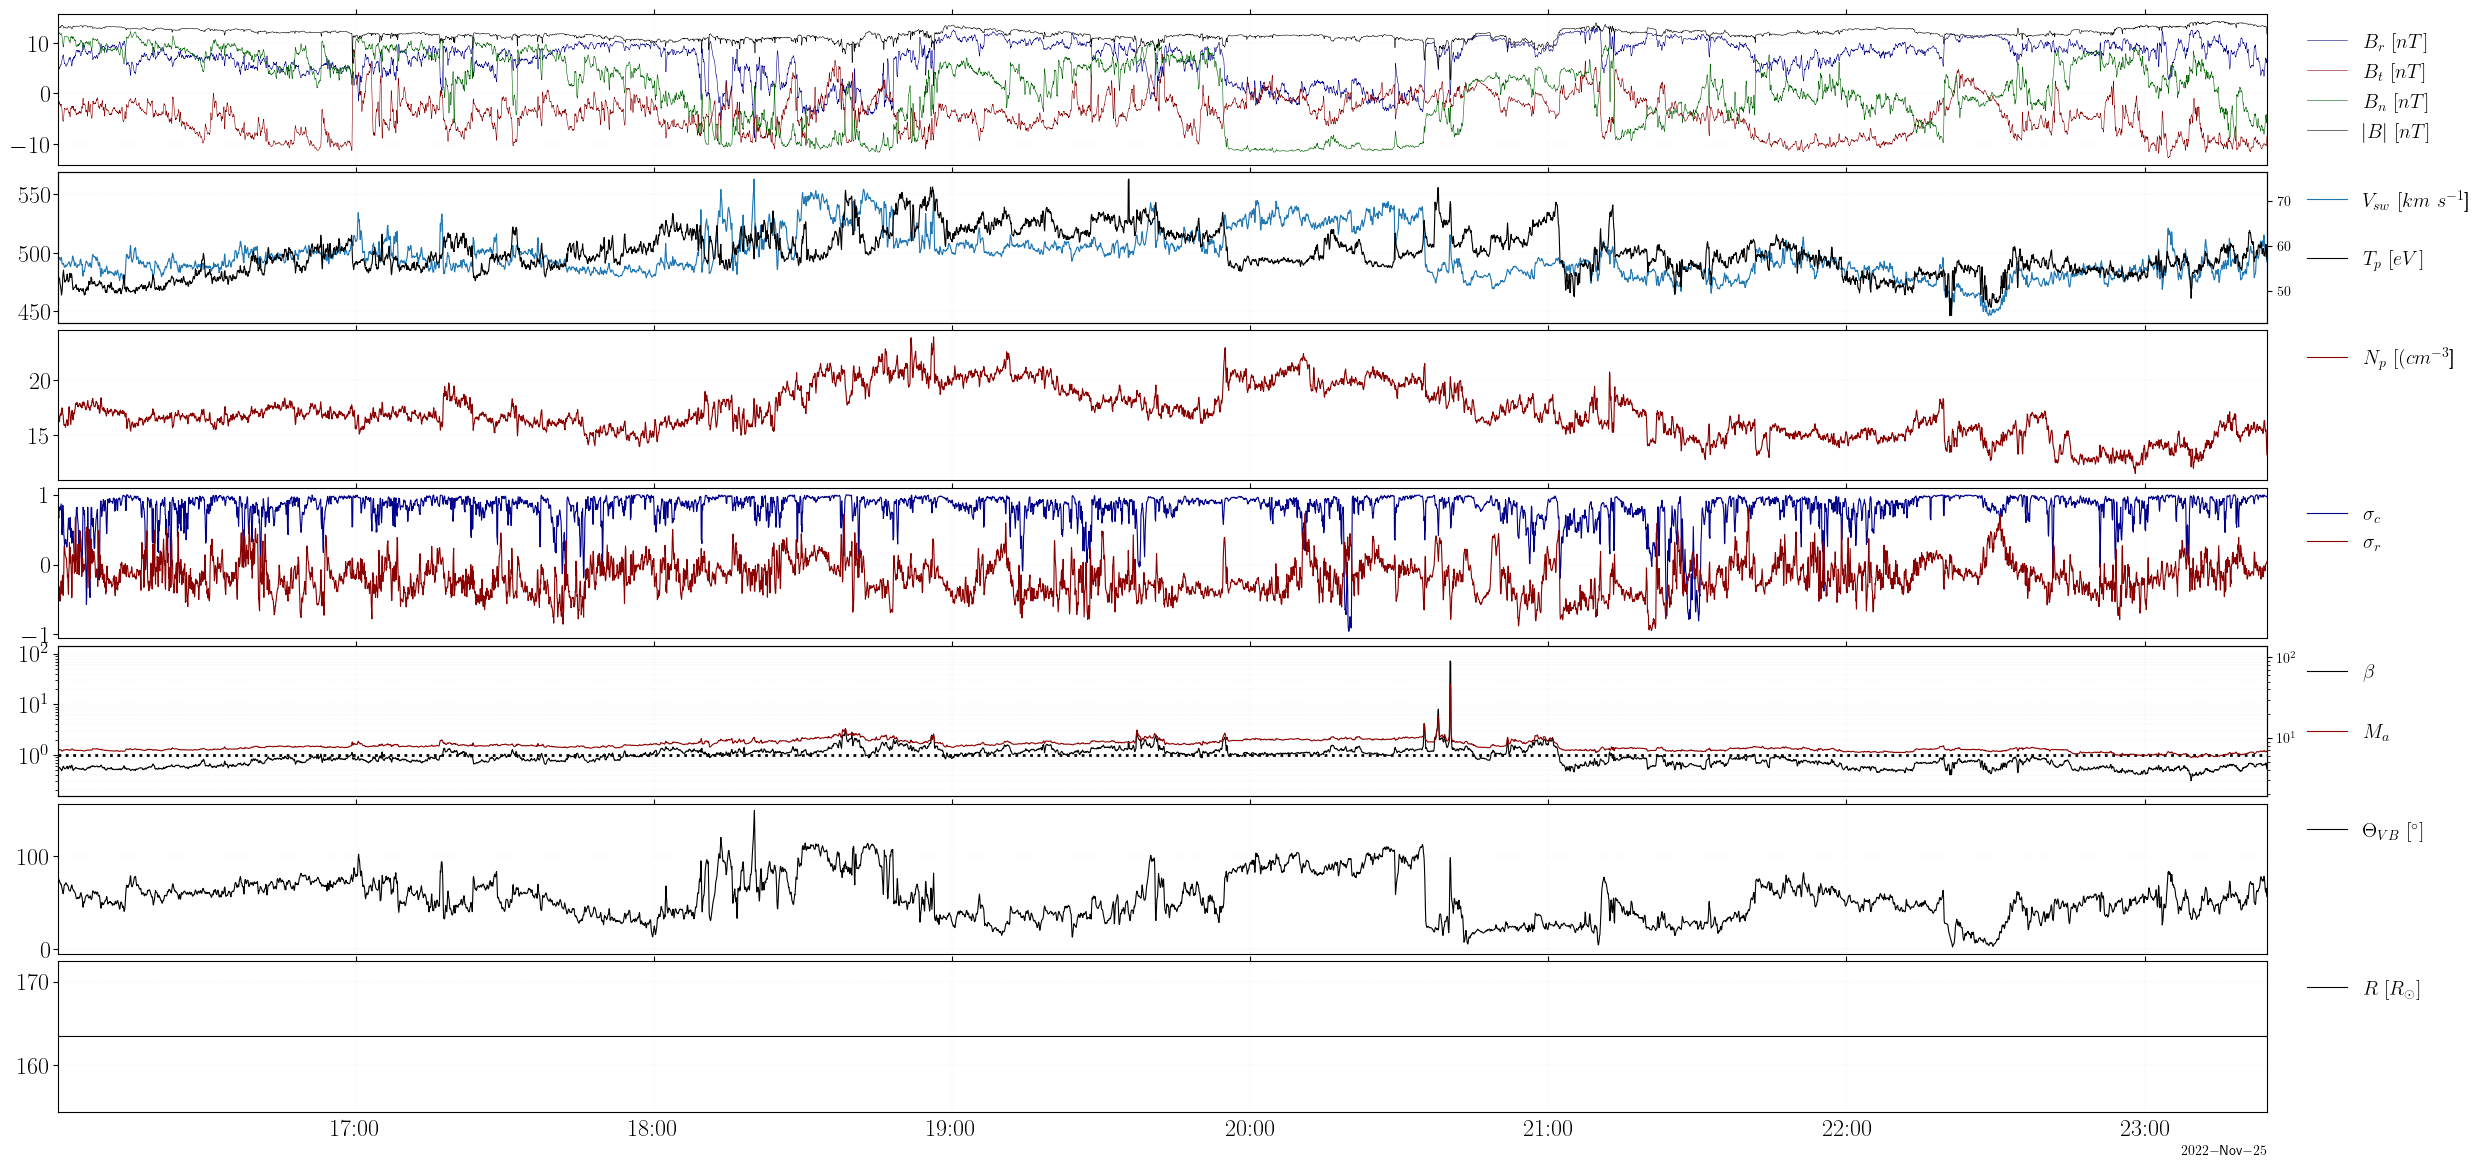

In [10]:
# user defined parameters
w                 = '10s'
sc                = 'SOLO'
label_size        = 'large'
legend_font_size  = 'x-large'

n_subplots        = 7                                     # number os subplots
my_dir            = '/Users/turbulator/work/MHDTurbPy/examples' #
format_2_return   = "%Y_%m_%d"                            # Format to save figures


figs.visualize_downloaded_intervals(
                                  sc                         ,
                                  fin['Par']['V_resampled'].rolling(w, center=True).mean() ,
                                  fin['Mag']['B_resampled'].rolling(w, center=True).mean() ,
                                  sig.rolling(w, center=True).mean()   ,
                                  my_dir,
                                  format_2_return  = "%Y_%m_%d",  #
                                  size             = label_size,
                                  font_size        = legend_font_size, 
                                  numb_subplots    = n_subplots
                                 )

